## Session 3: Battery kinetics and transport

- Recap of battery thermodynamics: 
    - Thermodynamics tells us what's possible, i.e. the equilibrium states when the battery is fully at rest. The electrochemical stability window is the voltage range within which the electrolyte should not decomposite (either via reduction or oxidation). 
    - The OCV is generally assumed to undergo Nernstian behavior. It can be experimentally measured by measuring the battery voltage when it is at rest. The OCV is affected by electrode structural changes, so will vary with SOC (as well as battery aging, or SOH). 
    - The electrochemical stability window is the voltage range within which the electrolytes are stable. Li-ion batteries operate slightly outside the range for standard organic solvents (liquid electrolytes), but this is ok because the SEI forms and maintains kinetic stability. 
    

- Kinetics give us information about rates of reactions, desired or undesired. 

- In ideality, we want lithium ions to move back and forth with 100% efficiency. In reality, some lithium ions are consumed and reacted away, especially considering that we are operating in a thermodynamically unstable environment. So, it's remarkable that lithium-ion batteries work as well as they do. Commercial cells can cycle at efficiencies of 99.995% or higher. $0.99995^{4000}\ =\ 81.9\%$ of initial capacity, and can operate at high voltages beyond the electrochemical stability window. This is largely thanks to kinetics - of SEI formation (which we will discuss in Session 4). 

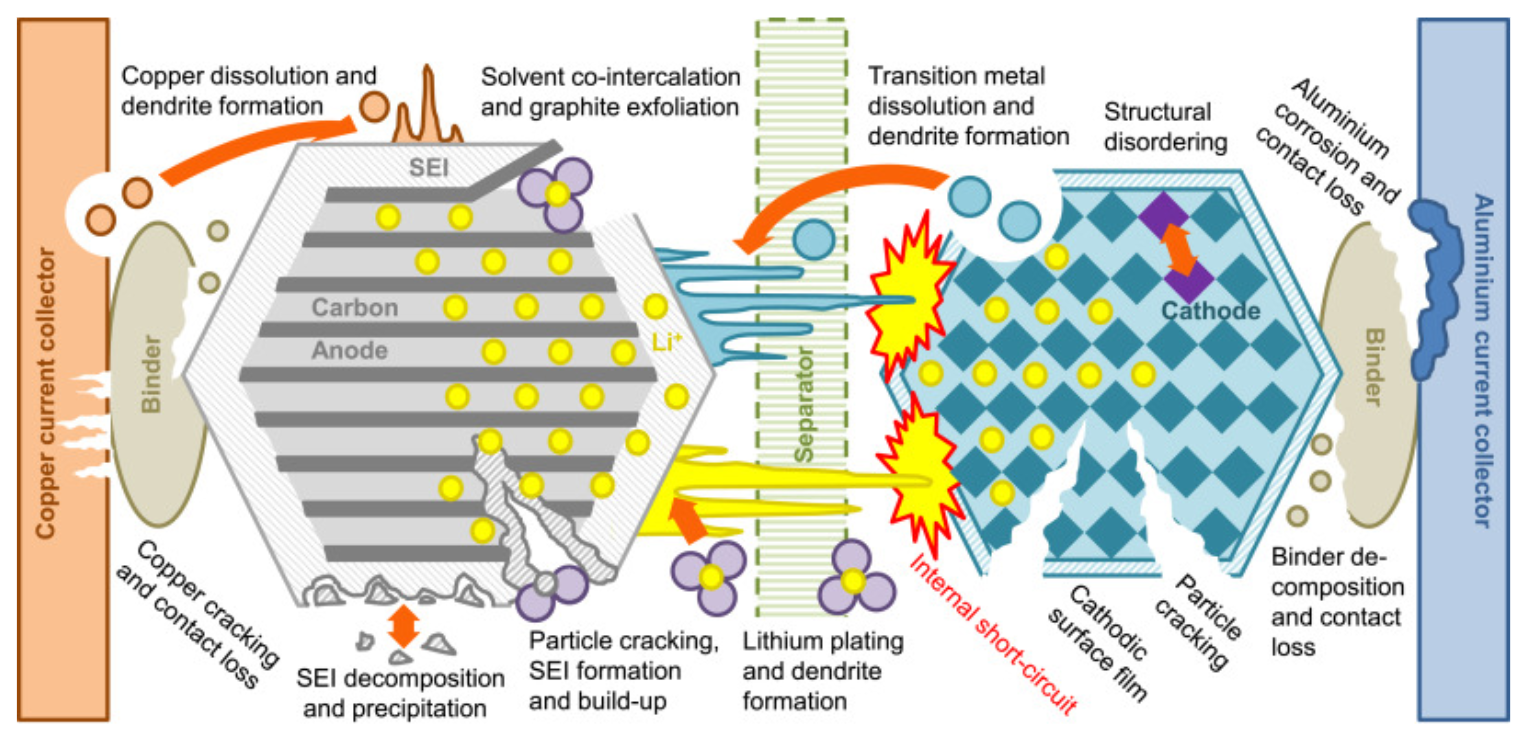

[ref: doi.org/10.1016/j.jpowsour.2016.12.011]


- Most rate constants (k) vary linearly with temperature as: ln(k) vs 1/T. The Arrhenius rate law is an exponential relationship that describes this. In other words, the slope of ln(k) vs 1/T is linear, and is equivalent to an activation energy that needs to be surmounted to go from A to B. 

$r[mol/L/s]\ =\ k[s^{-1}] c_0[mol/L] = A e^{-E_A / RT} c_0$


- This describes the transition from a reactant to a product over an intermediate state. The net rate of reaction is equal to the forward and backward reactions; in other words, ions or atoms will tend to hop back and forth, but predominantly in the direction that is kinetically favorable. Activation energies can be different for forward and backward reactions. 


### Butler-Volmer kinetics

What determines the rate of an electrochemical reaction? The current density: $j_{a}\ =\ Fc_{O}k/A$ 

From homogeneous kinetics, the rate of reaction is a function of the activation energy. Plugging this in:

$j_{a}\ =\ Fc_{R}k_0 e^{\alpha _a FE/RT}/A$

$j_{c}\ =\ -Fc_{O}k_0 e^{-\alpha _c FE/RT}/A$

$j_{net}\ =\ j_{a}\ +\ j_{c}$

$j = j_0(e^{\alpha _a F \eta / RT} - e^{-\alpha _c F \eta/RT})/A$

$j_0$ is the exchange current density (current at electrode surface at equilibrium), where 
$j_0\ =\ Fk_0 c_{O} e^{-\alpha _c FE_{rxn}/RT}/A$

- The exchange current is a kind of "idle current" for charge exchange across the interface, and determines a system's ability to deliver a net current. A large exchange current density means that even a low applied overpotential leads to a significant increase in measured current. 

$\alpha$ is the symmetry of the energy barrier (can be different for the anodic and cathodic reactions)

- We can plot this equation to see how the overpotential changes with applied current. 

- The difference between the cell potential when current is flowing and the equilibrium potential, is the overpotential ($\eta$). The overpotential is the energy required to drive an electrochemical reaction away from equilibrium. It is a combination of activation (or kinetic), ohmic, and mass transport contributions. Each electrode has its own overpotential contribution. 

### Activation overpotential

At small overpotentials, activation overpotential dominates (this expression is found by a Taylor expression of BV)

$j = -j_0F\eta/RT$

$R_{ct} = -\eta/j = RT/j_0F$


### Ohmic overpotential

at moderate overpotentials, there is a linear relationship.

$\eta = jR_{ohmic}$


### Mass transport overpotential

at large reductive overpotentials the anodic term of BV drops out:

$j = -j_0 e^{-\alpha _c F\eta / RT}$

**all of this describes the electrode/electrolyte interface of *one* electrode. For example, the graphite electrode, or the NMC electrode. An actual battery consists of both electrodes within one electrochemical cell. 




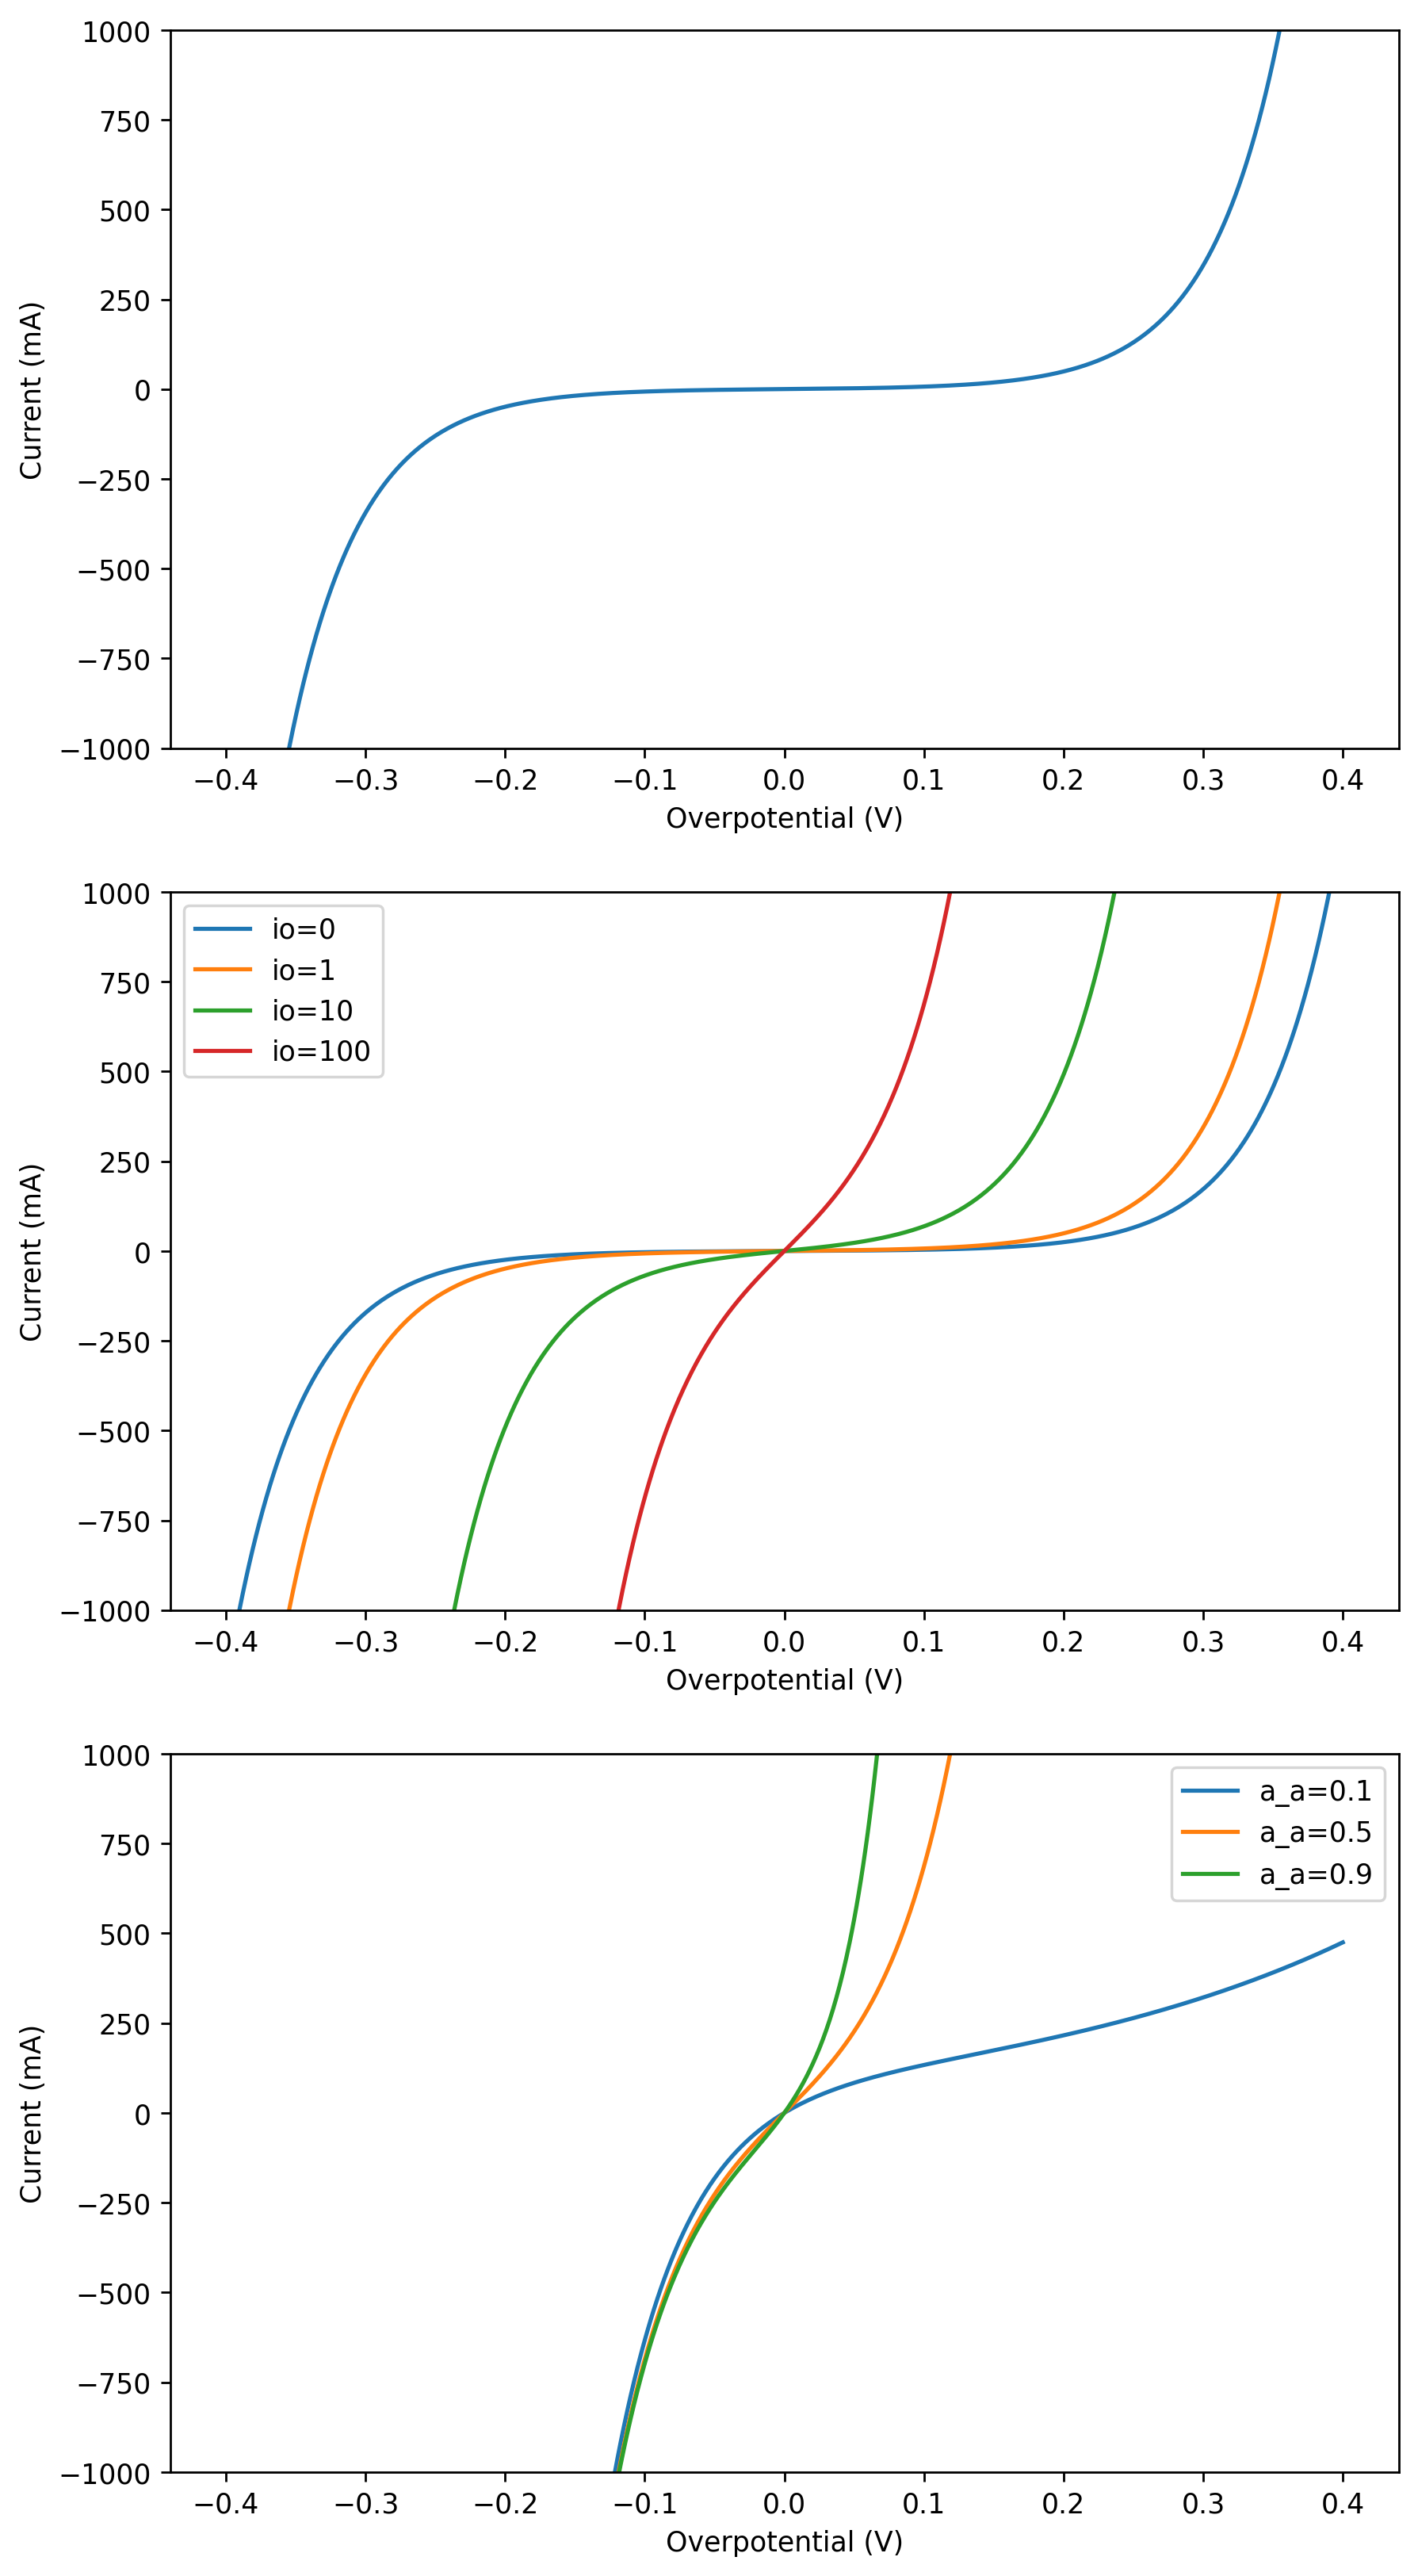

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

F = 96485 # Faradays Constant, C/mol
R = 8.314 # Ideal Gas Constant, J/mol-K

#Butler-Volmer Relationship
def BV(eta_s, T=298.0, aa=.5, ac=.5, io=1):
    anodic = np.exp((aa)*F*eta_s/(R*T))
    cathodic = np.exp((-ac)*F*eta_s/(R*T))
    return io*(anodic-cathodic)

fig = plt.figure(figsize=(8, 16), dpi=250)
ax1 = fig.add_subplot(311)
ax2 = fig.add_subplot(312)
ax3 = fig.add_subplot(313)

eta = np.linspace(-.4,.4,1000) # Voltage to "sweep"
ax1.plot(eta, BV(eta)) # Plot Potential vs. Current 

aa = 0.5 
ac = 0.5
i0 = [0.5, 1, 10, 100]

for i in i0:
    ax2.plot(eta,BV(eta,aa=aa,ac=ac,io=i),label="io=%.0f"%(i))
ax2.legend()

aa = [0.1, 0.5, 0.9]
for a in aa:
    ax3.plot(eta,BV(eta,aa=a,ac=ac,io=i),label="a_a=%.1f"%(a))
ax3.legend()

for ax in [ax1,ax2,ax3]:
    ax.set_xlabel('Overpotential (V)')
    ax.set_ylabel('Current (mA)')
    ax.set_ylim(-1000,1000)

plt.show()


### Connection to Li-ion battery charge and discharge

The figure below depicts one charge and discharge cycle, showing the measured cell voltage (solid lines) versus the estimated OCV (dashed lines).

- The measured cell voltage is the *difference* between the positive and the negative electrodes. The potentials of each electrode cannot be directly distinguished without the use of a reference electrode. 

- The measured cell voltage is higher than the OCV during charge because of positive overpotentials. Recall this overpotential is going to be a sum of the anode and cathode overpotentials. Each anode and cathode overpotential is then a combination of kinetic, ohmic and mass transport overpotentials. This overpotential in Li-ion batteries is predominantly from high internal cell resistance (electrolytes, interphases, electrode/current collector contact, electrode/electrolyte contact)

- Over many cycles, the measured cell voltage will creep up because of increase in overpotential. What can cause this? See first figure: particle cracking, SEI decomposition and continuous electrolyte degradation, contact loss (for the anode), and transition metal dissolution, particle cracking and structural disorder leading to possible gas formation (for the cathode). In the case of an internal short circuit, a drop in the cell voltage would instead be detected due to lower internal cell resistance.  

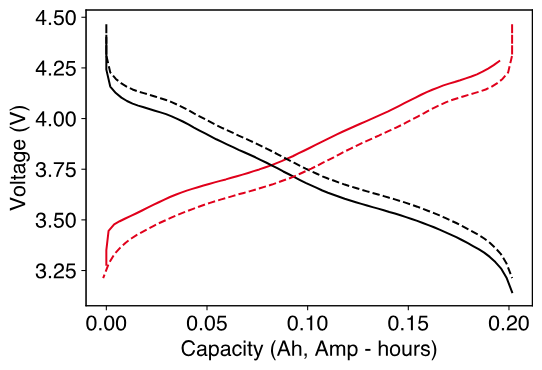

## Transport

Ionic species move due to the effect of an electric field (migration), or concentration gradients (diffusion). The movement of species controls the rate, and hence the current, and can be expressed as: $i\ =\ i_d\ +\ i_m$. Migration and diffusion may be in the same or the opposite directions (e.g. lithium reduction to lithium metal is an example of migration being in the same direction as diffusion; high concentrations of lithium ions in solution diffuse to low concentrations at the electrode surface, and the electric field drives lithium ions towards the surface). 

(ref: https://drive.google.com/file/d/1DrCd-oBi_sf7MfUvE_OQynF580GyQKso/view?usp=drive_link)

### Diffusion

Slow diffusion of ions through porous electrodes is the rate determining step in a Li-ion battery. For batteries, this was first explored by Weppner and Huggins in 1977 for the lithium-antimony alloy. A combination of transient and steady-state voltage measurements using a technique called "galvanostatic intermittent titration technique" or GITT was used to determine the diffusion coefficient. [Session 8]

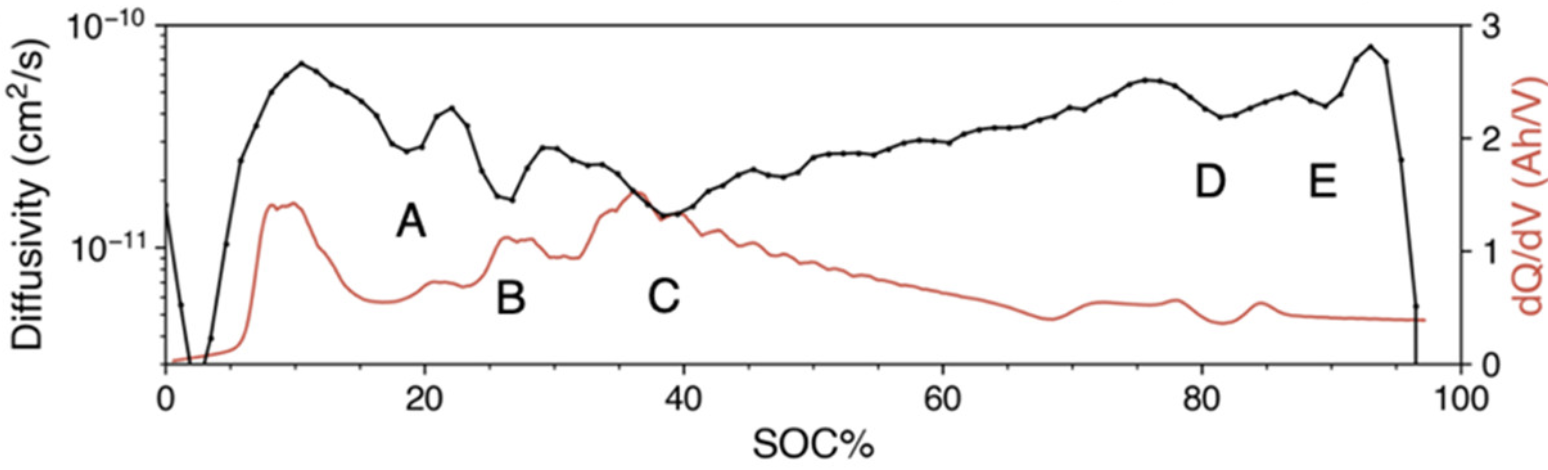

[ref: https://pubs.acs.org/doi/full/10.1021/acs.jpcc.0c09972]

### Transference number

The fraction of current carried by the cation relative to the anion in the electrolyte is called the transference number. Higher cation transference numbers implies that more of the current is carried by the cation. 

$t_j\ =\ i_j/i$ where $i_j\ =\ |z_j|FAu_jC_j \frac{\partial \phi}{\partial x}$ for species j. The current in the bulk solution is mainly driven by migration due to the electric field (concentration gradients are small)

- Measurable via the Bruce-Vincent method or NMR (nuclear magnetic resonance spectroscopy)
- Bruce-Vincent method uses a symmetric cell with two lithium metal electrodes and applies a small potential difference to induce a slight concentration gradient. The idea is, for small potential differences there is a steady-state current flow that can be used to determine the transference number of lithium ions because the diffusion and migration of the anion is exactly balanced. 

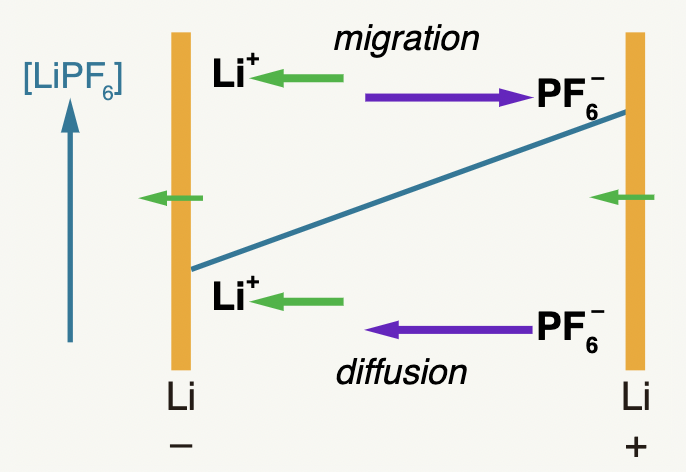

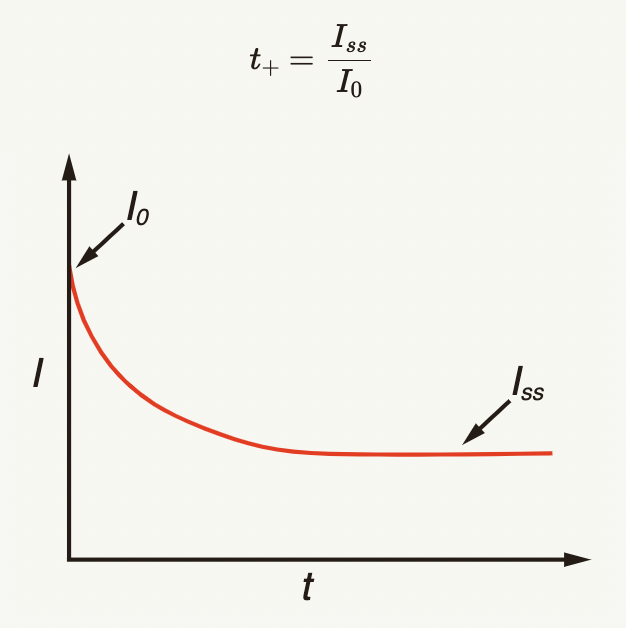

[ref: https://lithiuminventory.com/experimental-electrochemistry/transference-number-measurement/]

- As one might imagine, the above is subject to many assumptions, such as the use of very dilute electrolyte concentrations. 

### Ionic conductivity

The ionic conductivity determines the electrolyte's ability to transport ions, and is a function of ionic charge, salt concentration, temperature, diffusion coefficients, etc. 

- Can be measured via EIS [Ref: https://lithiuminventory.com/experimental-electrochemistry/eis/principles/]

- Typical ionic conductivity value of a Li-ion battery electrolyte is around 10 mS/cm (milliSiemens per centimeter) at room temperature, and at an electrolyte salt concentration of 1.2 M. Higher or lower salt concentrations decrease the ionic conductivity, as does decrease in temperature. 

- Why don't we use higher salt concentrations? (for instance, higher salt concentrations decrease the availability of free solvents and could improve electrolyte stability). Conductivity goes down, diffusivity goes down. 

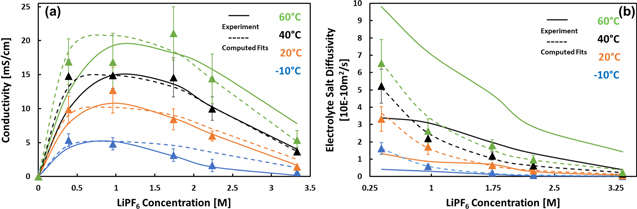

[ref: https://iopscience.iop.org/article/10.1149/1945-7111/aceca8]

### Transport in solid electrodes

The solid electrodes in Li-ion  batteries are porous composites which have a defined porosity and tortuosity. 

- Porosity is the volume fraction of pores (empty spaces): total volume - volume occupied by solid phase / total volume

- Tortuosity is the "tortuous" path traversed by ions through the porous electrode (versus a straight line path)

- A typical expression used to characterize porosity and tortuosity of porous electrodes is: $D_{eff}\ =\ \frac{\epsilon}{\tau}D$ where $\epsilon$ is porosity and $\tau$ tortuosity. Effective diffusivity is that measured of the porous electrode soaked in electrolyte. 

- It is then common practice to assume Bruggeman's relationship for porous media with spherical particles: $\tau\ =\ \epsilon ^{-0.5}$ though this has been shown to grossly underestimate the tortuosity of real battery electrodes

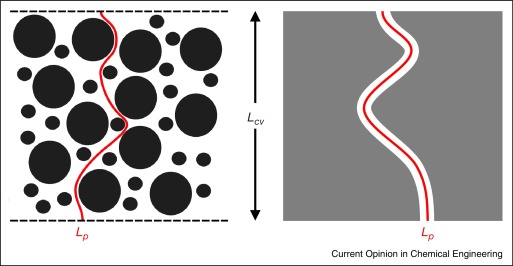

[Ref: https://www.sciencedirect.com/science/article/pii/S2211339816300119]

- Commonly measured values of tortuosity for Li-ion battery electrodes range between 3 - 9 

[Ref: doi.org/10.1149/2.062302jes]

### Estimating porosity using X-ray CT

One way of measuring electrode porosity is via image reconstruction from X-ray CT. X-ray CT scans provide 2D slices of the 3D volume. In each 2D slice, we observe active materials and the inactive materials, which have differences in X-ray absorption intensity. By comparing the pixel greyscale values, we can segment the image into pixels that are part of the active material, and pixels that are not. From this ratio, we can determine the porosity, or the pore volume fraction. This technique does have limitations - very small pores that are close to the size of the pixel resolution cannot be easily distingished, and may result in noise / error. The segmentation parameters may also depend on how the user implements the protocol. 

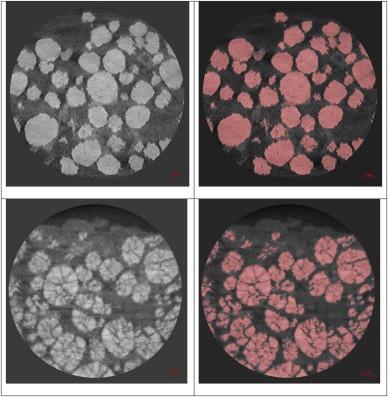

### How do we model Li-ion battery kinetics and transport?

The standard model of a Li-ion battery is the Newman model (developed by John Newman and colleagues). Also called the Doyle-Fuller-Newman (DFN) model. It is a physics-based model with many coupled non-linear partial differential equations, taking into account parameters such as electrolyte concentration, electrode active material concentration, initial conditions. 

It was originally written in Fortran and called 'dualfoil': https://www.cchem.berkeley.edu/~jsngrp/fortran.html 

PyBaMM is a modern day implementation: https://colab.research.google.com/drive/16wughdaBaoR4Sz4aKumtbKeuom7oCike?usp=sharing
PyBaMM is well documented: https://docs.pybamm.org/en/latest/source/examples/notebooks/getting_started/tutorial-1-how-to-run-a-model.html 
For further reading: https://openresearchsoftware.metajnl.com/articles/10.5334/jors.309


In [4]:
import pybamm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
### Run default PyBaMM DFN model

model = pybamm.lithium_ion.DFN() 
sim = pybamm.Simulation(model)
sim.solve([0, 3600]) # Solve for time = 0 to time = 3600 seconds 
solution = sim.solution
sim.plot()


interactive(children=(FloatSlider(value=0.0, description='t', max=1.0, step=0.01), Output()), _dom_classes=('w…

In [6]:
'''
Show all the parameters that are available/calculated
'''
model = pybamm.lithium_ion.DFN()
for i in model.variable_names():
    print(i)

Time [s]
Time [min]
Time [h]
x [m]
x_n [m]
x_s [m]
x_p [m]
r_n [m]
r_p [m]
Current variable [A]
Total current density [A.m-2]
Current [A]
C-rate
Discharge capacity [A.h]
Throughput capacity [A.h]
Discharge energy [W.h]
Throughput energy [W.h]
Porosity
Negative electrode porosity
X-averaged negative electrode porosity
Separator porosity
X-averaged separator porosity
Positive electrode porosity
X-averaged positive electrode porosity
Porosity change
Negative electrode porosity change [s-1]
X-averaged negative electrode porosity change [s-1]
Separator porosity change [s-1]
X-averaged separator porosity change [s-1]
Positive electrode porosity change [s-1]
X-averaged positive electrode porosity change [s-1]
Negative electrode interface utilisation variable
X-averaged negative electrode interface utilisation variable
Negative electrode interface utilisation
X-averaged negative electrode interface utilisation
Positive electrode interface utilisation variable
X-averaged positive electrode inte

Text(0.5, 0, 'Time [s]')

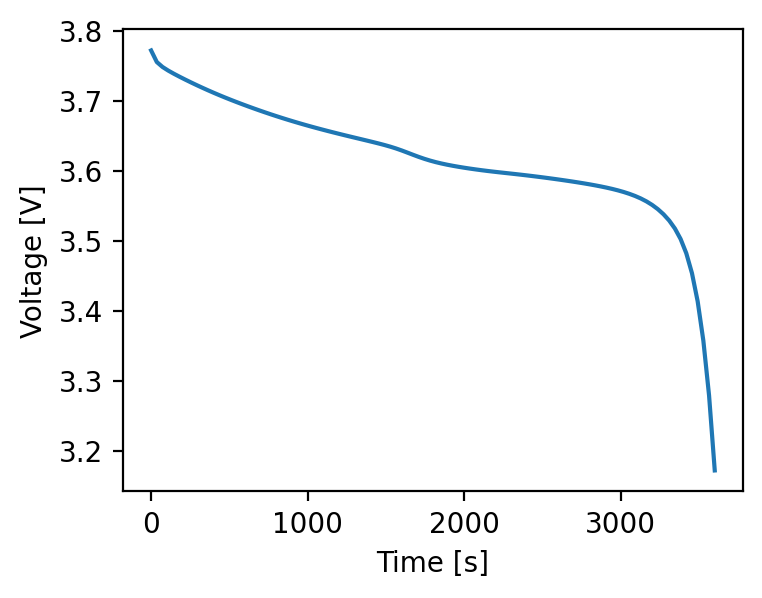

In [7]:
## Plot voltage vs time 
x = solution['Time [s]'].entries # time [s]
y = solution["Battery voltage [V]"].entries #voltage [V]
xlabel = 'Time [s]'
ylabel = 'Voltage [V]'

#Plotting
fig=plt.figure(dpi=200,figsize=(4,3))
ax=fig.add_subplot(111)
ax.plot(x,y)
ax.set_ylabel(ylabel)
ax.set_xlabel(xlabel)

Text(0.5, 0, 'Time (h)')

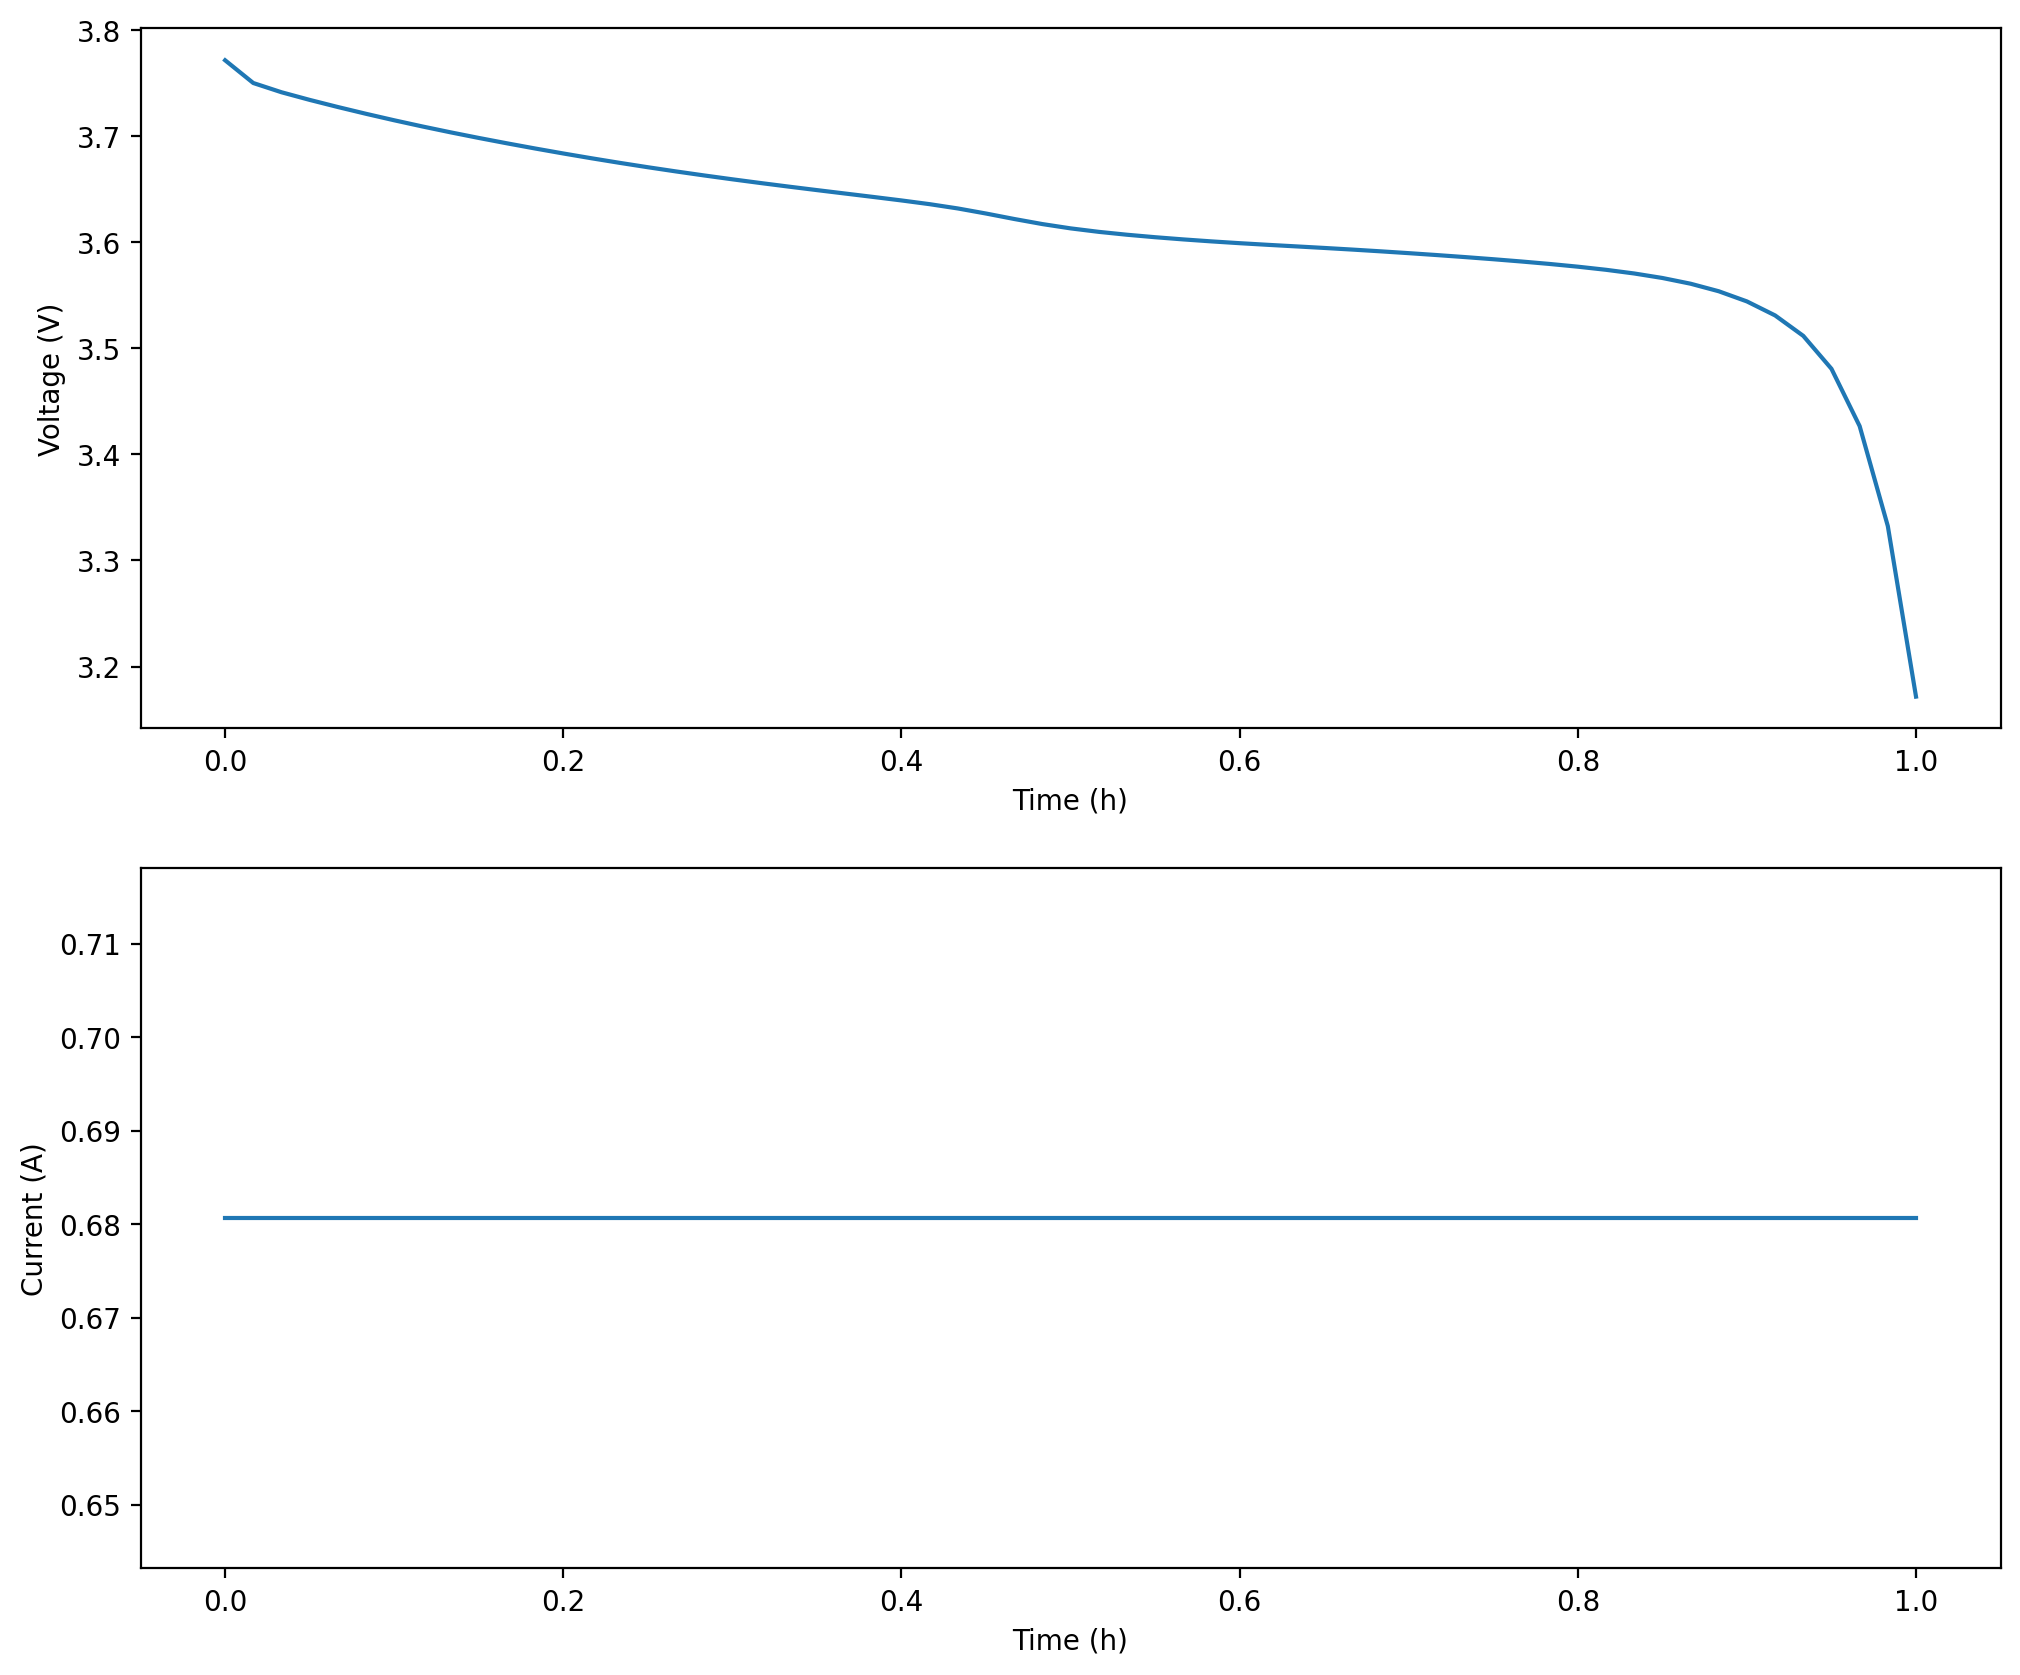

In [8]:
### Apply a custom experiment: discharge at 1C for 1 hour and plot 

experiment = pybamm.Experiment(
["Discharge at 1C for 1 hour"]
)

model = pybamm.lithium_ion.DFN()
sim = pybamm.Simulation(model, experiment=experiment)
sim.solve()
solution = sim.solution
fig=plt.figure(dpi=200,figsize=(12,10))

x = solution['Time [s]'].entries # time [s]
y = solution["Battery voltage [V]"].entries #voltage [V]
xlabel = 'Time (h)'
ylabel = 'Voltage (V)'

#Plotting
ax1 = fig.add_subplot(211)
ax1.plot(x/3600,y)
ax1.set_ylabel(ylabel)
ax1.set_xlabel(xlabel)

x = solution['Time [s]'].entries # time [s]
x = x/3600
y = solution['Current [A]'].entries #voltage [V]
xlabel = 'Time (h)'
ylabel = 'Current (A)'

#Plotting
ax2=fig.add_subplot(212)
ax2.plot(x,y)
ax2.set_ylabel(ylabel)
ax2.set_xlabel(xlabel)

CasADi - 2025-04-17 09:52:45 WARNING("roots:g failed: Inf detected for output x, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:393]
CasADi - 2025-04-17 09:52:45 WARNING("roots:g failed: Inf detected for output x, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:393]
CasADi - 2025-04-17 09:52:45 WARNING("roots:g failed: Inf detected for output x, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:393]
CasADi - 2025-04-17 09:52:45 WARNING("roots:g failed: Inf detected for output x, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:393]
CasADi - 2025-04-17 09:52:45 WARNING("roots:g failed: Inf detected for output x, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:393]
CasADi - 2025-04-17 09:52:45 WARNING("roots:g failed: Inf detected for output x, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:393]
CasADi - 2025-04-17 09:52:45 WARNING("roots:g failed: Inf detected for output x, at (row 0, col 0).") [.../casadi/core/oracle_function.c

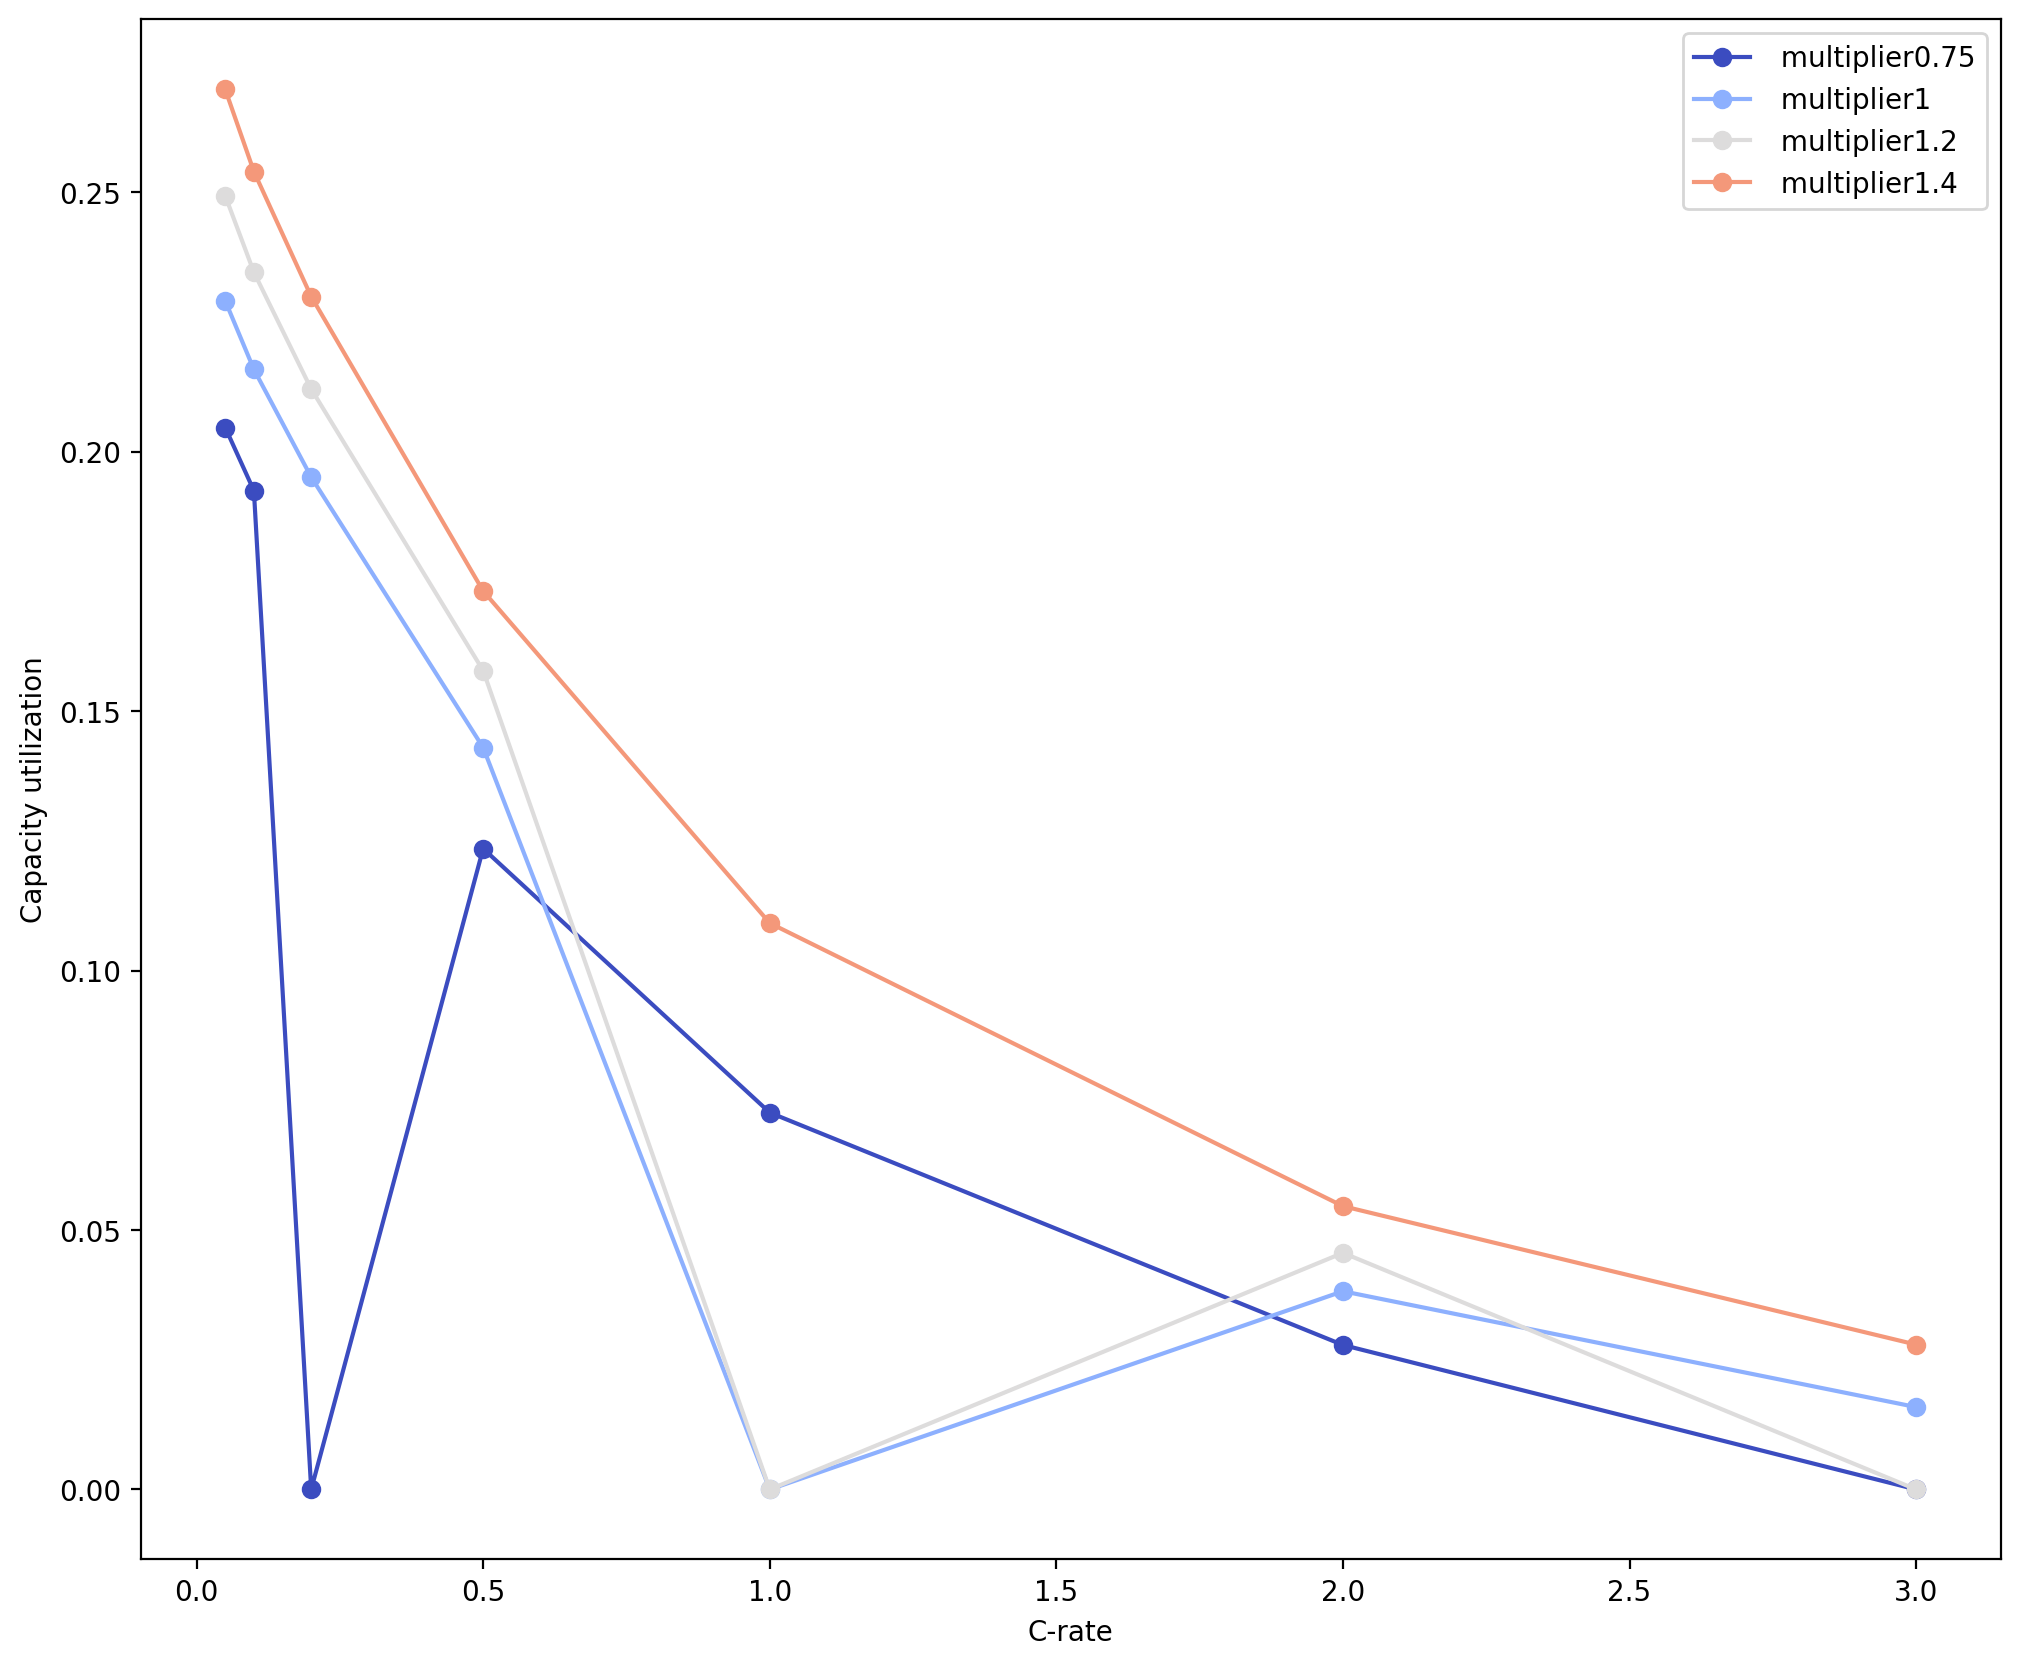

In [ ]:
### Case study: simulate rate capability with varying electrode thicknesses

C_rates = [0.05, 0.1, 0.2, 0.5, 1, 2, 3] # from C/20 to 3C
t_multiplier = [0.75, 1, 1.2, 1.4] #
temp = [20]

#Load parameters
params = pybamm.ParameterValues("Chen2020") #Use built-in parameter set from Chen 2020

#Initiate plot
fig = plt.figure(dpi=200,figsize=(12,10))
ax = fig.add_subplot(111)
colormap = plt.cm.get_cmap('coolwarm')

#Initial thicknesses
cell_capacity = params['Nominal cell capacity [A.h]']
cell_current = params['Current function [A]']
og_cathode_thick = params['Positive electrode thickness [m]']
og_cathode_por = params['Positive electrode porosity']
og_anode_thick = params['Negative electrode thickness [m]']
og_anode_por = params['Negative electrode porosity']
# temp = params['Ambient temperature [K]']

# Iterate varying electrode thicknesses 
for n, t in enumerate(t_multiplier):

    #Scale electrode geometry by the thickness factor
    params['Positive electrode thickness [m]'] = og_cathode_thick
    params['Negative electrode thickness [m]'] = og_anode_thick
    params['Positive electrode porosity'] = og_cathode_por
    params['Negative electrode porosity'] = og_anode_por
    params['Positive electrode active material volume fraction'] = 1-params['Positive electrode porosity']
    params['Negative electrode active material volume fraction'] = 1-params['Negative electrode porosity']
    params['Nominal cell capacity [A.h]'] = cell_capacity # Assume capacity scales linearly with thickness 
    params['Current function [A]'] = cell_current
    params['Ambient temperature [K]'] = 300*t
 

    cathode_thickness_str = str(np.round(params['Positive electrode thickness [m]']*1E6,1)) + ' um'
    utilization_array = []

    #Run rate sweep
    for C_rate in C_rates:

        #Perform simulation
        period = (3600 * 1/C_rate)/10
        experiment = pybamm.Experiment(["Discharge at {}C until 3.0V".format(C_rate)], period="{} seconds".format(period)) # 
        model = pybamm.lithium_ion.DFN() # Choose default DFN model
        solver = pybamm.CasadiSolver(atol=1e-3, rtol=1e-3, mode="safe") # Choose solver
        sim = pybamm.Simulation(model, experiment=experiment, 
                    parameter_values=params, solver=solver) # Set simulation parameters
        
        try: # Catch convergence error when electrolyte depleted at way too high rates
            sim.solve() # Run simulation
            solution = sim.solution # Get simulation result
            tcr = solution["Time [h]"].entries*C_rate
            utilization = tcr[-1]
        except:
            utilization = 0
        utilization_array.append(utilization)

    ax.plot(C_rates,utilization_array,'o-',label=' multiplier'+str(t), color=colormap(n/len(t_multiplier)))

ax.set_ylabel('Capacity utilization')
ax.set_xlabel('C-rate')
ax.legend(loc='best')

In [18]:
### Another example: manually set parameters

import pybamm
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt

color_map = plt.cm.get_cmap('coolwarm') 
electrode_thicknesses = [8e-05, 15.1e-05, 40e-05] #in meters

### Function for solving DFN with known parameters
def set_experiment_and_solve(parameterset, e):
    #uses modified parameter set
    #==============================================================
    model = pybamm.lithium_ion.DFN()
    params = pybamm.ParameterValues(parameterset)
    # print(params) 

    # Manually set some parameters https://docs.pybamm.org/en/latest/source/examples/notebooks/getting_started/tutorial-4-setting-parameter-values.html
    params['Negative electrode thickness [m]'] = e
    params['Positive electrode thickness [m]'] = e

    #------------------------------------------------- Determine cycling protocol to simulate
    experiment = pybamm.Experiment([
        "Rest for 1 hour",
        ("Discharge at C/5 for 10 hours or until 2.8 V",
        "Rest for 1 hour",
        "Charge at 2C until 5 V",
        "Rest for 1 hour"
        )*1
    ])

    sim = pybamm.Simulation(model, experiment=experiment, parameter_values=params)
    safe_solver = pybamm.CasadiSolver(mode="safe") # https://docs.pybamm.org/en/latest/source/api/solvers/index.html

    '''
    The CasadiSolver can operate in a number of modes, including “safe” (default) and “fast”. Safe mode performs step-and-check integration and 
    supports event handling (e.g. you can integrate until you hit a certain voltage), and is the recommended for simulations of a full charge or discharge. 
    Fast mode performs direct integration, ignoring events, and is recommended when simulating a drive cycle or other simulation where no events should be triggered.
    '''
    sim.solve(solver=safe_solver)

    return sim.solution

for n,e in enumerate(electrode_thicknesses):
    solution = set_experiment_and_solve("Ecker2015", e) # Use parameters from a specific reference paper stored in PyBAMM repo
    solution.plot()
    # time = solution["Time [h]"].entries
    # voltage = solution["Voltage [V]"].entries
    # ax.plot(time, voltage, lw=2, color=color_map(n/len(electrode_widths)))
    # ax.set_xlabel("Time [h]", fontsize=15)
    # ax.set_ylabel("Voltage [V]", fontsize=15)
plt.show()


The linesearch algorithm failed with too small a step.
The linesearch algorithm failed with too small a step.
The linesearch algorithm failed with too small a step.
The linesearch algorithm failed with too small a step.
The linesearch algorithm failed with too small a step.
At t = 403.982 and h = 3.72676e-14, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 163.983 and h = 1.28161e-15, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 43.9826 and h = 2.74712e-17, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 43.9827 and h = 2.00903e-14, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 6.4827, , mxstep steps taken before reaching tout.
At t = 6.4827 and h = 1.25141e-17, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 6.4827 and h = 1.43782e-18, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 1.7952, , mxstep steps taken before reaching tout.
At t = 1.79

interactive(children=(FloatSlider(value=0.0, description='t', max=9.122407073603426, step=0.09122407073603427)…

At t = 488.564 and h = 2.85829e-16, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 8.56475 and h = 3.28119e-14, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 8.56476, , mxstep steps taken before reaching tout.
At t = 8.56476 and h = 3.07449e-18, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 8.56476, , mxstep steps taken before reaching tout.
At t = 8.56476, , mxstep steps taken before reaching tout.
At t = 8.56476 and h = 9.27459e-18, the corrector convergence failed repeatedly or with |h| = hmin.
2024-04-17 23:52:54.300 - [ERROR] callbacks.on_experiment_error(224): Simulation error: Maximum number of decreased steps occurred at t=46440.0 (final SolverError: 'Error in Function::call for 'F' [IdasInterface] at .../casadi/core/function.cpp:1401:
Error in Function::call for 'F' [IdasInterface] at .../casadi/core/function.cpp:330:
.../casadi/interfaces/sundials/idas_interface.cpp:596: IDASolve returned "IDA_CONV_FAIL

interactive(children=(FloatSlider(value=0.0, description='t', max=12.0, step=0.12), Output()), _dom_classes=('…

interactive(children=(FloatSlider(value=0.0, description='t', max=14.20365937215284, step=0.1420365937215284),…

In [32]:
def set_experiment_and_solve(parameterset):
    model = pybamm.lithium_ion.DFN()
    params = pybamm.ParameterValues(parameterset)

    experiment = pybamm.Experiment([
        ("Discharge at 2 W for 2 hours",
        "Rest for 1 hour",
        "Charge at 200 mW for 45 minutes",
        "Rest for 1 hour"
        )*1
    ])

    sim = pybamm.Simulation(model, experiment=experiment, parameter_values=params)
    safe_solver = pybamm.CasadiSolver(mode="safe") # https://docs.pybamm.org/en/latest/source/api/solvers/index.html
    sim.solve(solver=safe_solver)

    return sim.solution

solution = set_experiment_and_solve("Ecker2015") # Use parameters from a specific reference paper stored in PyBAMM repo
solution.plot()
    # time = solution["Time [h]"].entries
    # voltage = solution["Voltage [V]"].entries
    # ax.plot(time, voltage, lw=2, color=color_map(n/len(electrode_widths)))
    # ax.set_xlabel("Time [h]", fontsize=15)
    # ax.set_ylabel("Voltage [V]", fontsize=15)
plt.show()

At t = 462.85 and h = 2.7733e-19, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 222.85 and h = 5.87308e-20, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 102.85 and h = 1.27169e-18, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 42.8498 and h = 8.30835e-22, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 5.34983 and h = 1.99551e-18, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 5.34983 and h = 1.99573e-18, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 5.34983 and h = 1.99544e-18, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 0.66232 and h = 3.96087e-20, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 0.66232 and h = 3.96281e-20, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 0.66232 and h = 4.09092e-20, the corrector convergence failed repeatedly or with |h| = hmin.
At t

interactive(children=(FloatSlider(value=0.0, description='t', max=1002.7981655619627, step=10.027981655619627)…

### Lithium "dendrite" formation 

Growth of lithium "dendrites" is widely stated as a failure mode that causes an internal short circuit and battery failure. Why does lithium plate "dendritically"? 

- The prevailing understanding is derived from dendrites in aqueous copper electrodeposition, where sufficiently high currents cause the concentration of cations at the electrode surface to decrease to zero after some amount of time (due to diffusion limitation). This causes ions to plate onto surface protrusions, which amplifies dendritic growth. 

- With lithium, this is observed even at low current densities much below the diffusion limited current density. These growths are described as "whisker-like" or "mossy". It has been suggested that the mossy growth occurs due to plating at the roots at low currents, rather than the tips of protrusions at higher currents. 

[ref: https://pubs.rsc.org/en/content/articlehtml/2021/xx/c6ee01674j]

How do we prevent dendrites from shorting the cell? 

- According to Monroe Newman: treating dendrite growth as an interface undergoing surface roughening, this surface deformation can be mechanically suppressed if the separate shear modulus is about twice that of lithium. They find this by taking a modified Butler-Volmer expression to account for the electrochemical potential change induced by local strain if there is a growth/protrusion. 

- They proposed, where $\Delta \mu _e^-$ is the deformation parameter that can be further expressed as a function of thermodynamic parameters (surface energy, stress tensor, partial molar volume from eqn of motion). Further, the stress of an isotropic, elastic material can be written as a function of strain and shear modulus which can be measured experimentally. Strain from overall displacement, shear modulus from othe stress-strain curve. 

$i_n\ =\ i_0 e^{\frac{(1-\alpha _a) \Delta \mu _e^-}{RT}}[e^{\frac{\alpha _a F \eta }{RT}} - e^{\frac{-\alpha _c F \eta }{RT}}]$

- Based on the Monroe Newman model: dendrite growth should be inhibited when the electrolyte shear modulus is more than twice that of lithium, such that the electrolyte can sustain electrode deformation due to non-uniform electrodeposition. 

- But: dendrite penetration is observed even in very high modulus oxide electrolytes. There are several hypotheses as to why: very high local forces imparted by nanoscale lithium deposits; high electronic conductivity in the electrolyte leading to lithium reduction inside the electrolyte


## Quiz 2

https://drexel.qualtrics.com/jfe/form/SV_cY2tyETx98ikXhI